In [67]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set path to event files
evts_path = "/Users/sambrown04/Documents/SURF/Events/2010_2010Events2stas"

In [68]:
# storing events in data frame for use
events_list = [] # list of pandas dataframes

for evt_path in os.listdir(evts_path): # loop over each file name in directory
    full_path = os.path.join(evts_path, evt_path) # joins directory path and file name
    print(f"Loading {evt_path}") 
    event = pd.read_csv(full_path, sep="\t") # load in
        
    events_list.append(event)

Loading 2010-11-18_23-03-00.evt
Loading 2010-08-09_01-24-45.evt
Loading 2010-03-13_00-28-30.evt
Loading 2010-02-18_08-46-45.evt
Loading 2010-06-24_08-31-00.evt
Loading 2010-06-17_14-04-45.evt
Loading 2010-09-20_20-30-30.evt
Loading 2010-09-04_22-31-30.evt
Loading 2010-05-06_21-24-45.evt
Loading 2010-02-22_19-26-45.evt
Loading 2010-07-15_12-19-45.evt
Loading 2010-06-01_04-24-45.evt
Loading 2010-12-14_11-10-00.evt
Loading 2010-11-07_14-18-00.evt
Loading 2010-12-04_21-10-00.evt
Loading 2010-10-06_06-29-45.evt
Loading 2010-03-14_21-05-00.evt
Loading 2010-10-29_18-28-00.evt
Loading 2010-01-20_14-16-45.evt
Loading 2010-06-25_01-09-45.evt
Loading 2010-09-22_10-24-45.evt
Loading 2010-04-03_05-07-00.evt
Loading 2010-06-17_04-19-45.evt
Loading 2010-02-01_10-46-45.evt
Loading 2010-07-23_10-00-30.evt
Loading 2010-03-09_18-10-00.evt
Loading 2010-03-26_19-01-45.evt
Loading 2010-05-17_04-04-45.evt
Loading 2010-01-15_15-30-00.evt
Loading 2010-01-11_20-34-45.evt
Loading 2010-11-06_23-33-00.evt
Loading 

In [69]:
events_list[1].head()

,Unnamed: 0,time,la01x,la01y,la01z,la01res,la01res_avg,la02x,la02y,la02z,...,ws05res,ws05res_avg,slw1x,slw1y,slw1z,slw1res,slw1res_avg,sum_res_avg,ressum,event
0,1267375,2010-08-09 01:24:45,NaN,NaN,NaN,NaN,NaN,-277809.020278,-560456.459927,92.7835,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415259,0.457289,1.0
1,1267376,2010-08-09 01:25:00,NaN,NaN,NaN,NaN,NaN,-277809.020313,-560456.458221,92.7843,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415259,0.458021,1.0
2,1267377,2010-08-09 01:25:15,NaN,NaN,NaN,NaN,NaN,-277809.014236,-560456.452791,92.7856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415259,0.458021,1.0
3,1267378,2010-08-09 01:25:30,NaN,NaN,NaN,NaN,NaN,-277809.021350,-560456.456694,92.7808,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415259,0.458021,1.0
4,1267379,2010-08-09 01:25:45,NaN,NaN,NaN,NaN,NaN,-277809.021721,-560456.452458,92.7886,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415259,0.458021,1.0


In [71]:
start_times = []
for event in events_list:
    start_times.append(event['time'][0])
    

In [72]:
print(start_times)

['2010-11-18 23:03:00', '2010-08-09 01:24:45', '2010-03-13 00:28:30', '2010-02-18 08:46:45', '2010-06-24 08:31:00', '2010-06-17 14:04:45', '2010-09-20 20:30:30', '2010-09-04 22:31:30', '2010-05-06 21:24:45', '2010-02-22 19:26:45', '2010-07-15 12:19:45', '2010-06-01 04:24:45', '2010-12-14 11:10:00', '2010-11-07 14:18:00', '2010-12-04 21:10:00', '2010-10-06 06:29:45', '2010-03-14 21:05:00', '2010-10-29 18:28:00', '2010-01-20 14:16:45', '2010-06-25 01:09:45', '2010-09-22 10:24:45', '2010-04-03 05:07:00', '2010-06-17 04:19:45', '2010-02-01 10:46:45', '2010-07-23 10:00:30', '2010-03-09 18:10:00', '2010-03-26 19:01:45', '2010-05-17 04:04:45', '2010-01-15 15:30:00', '2010-01-11 20:34:45', '2010-11-06 23:33:00', '2010-02-02 22:25:00', '2010-06-26 02:06:00', '2010-09-09 20:04:45', '2010-01-19 15:00:00', '2010-10-15 18:43:15', '2010-01-27 12:05:00', '2010-05-28 02:09:45', '2010-02-27 05:25:00', '2010-12-02 13:08:00', '2010-12-08 16:05:00', '2010-03-06 19:05:00', '2010-05-30 03:19:45', '2010-03-2

In [75]:
time_series = pd.to_datetime(start_times)

df = pd.DataFrame({'start_time': time_series})

In [78]:
df['hour'] = df['start_time'].dt.hour
df['day_of_week'] = df['start_time'].dt.dayofweek  # Monday=0, Sunday=6
df['month'] = df['start_time'].dt.month
df['date'] = df['start_time'].dt.date

In [8]:
df.head()

,start_time,hour,day_of_week,month,date
0,2010-11-18 23:03:00,23,3,11,2010-11-18
1,2010-08-09 01:24:45,1,0,8,2010-08-09
2,2010-03-13 00:28:30,0,5,3,2010-03-13
3,2010-02-18 08:46:45,8,3,2,2010-02-18
4,2010-06-24 08:31:00,8,3,6,2010-06-24


([<matplotlib.axis.XTick at 0x15464e3d0>,
 [Text(0, 0, 'Mon'),
  Text(1, 0, 'Tue'),
  Text(2, 0, 'Wed'),
  Text(3, 0, 'Thu'),
  Text(4, 0, 'Fri'),
  Text(5, 0, 'Sat'),
  Text(6, 0, 'Sun')])

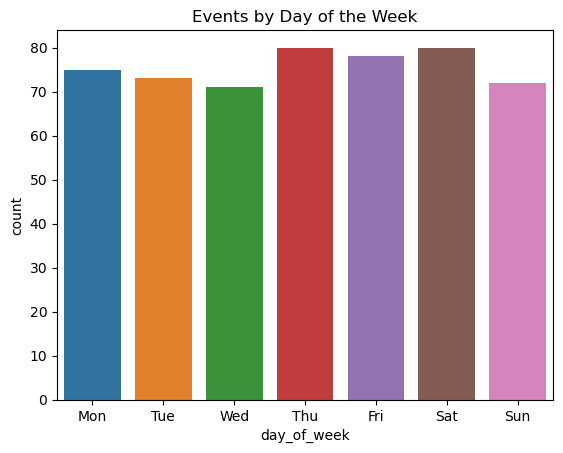

In [9]:
sns.countplot(x='day_of_week', data=df)
plt.title("Events by Day of the Week")
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

Text(0.5, 23.52222222222222, 'Hour of Day')

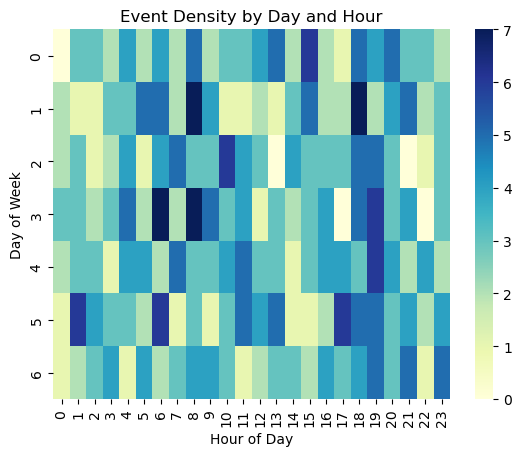

In [10]:
pivot = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Event Density by Day and Hour')
plt.ylabel('Day of Week')
plt.xlabel('Hour of Day')

In [33]:
df = df.sort_values('start_time').reset_index(drop=True)

In [37]:
df['time_diff_min'] = df['start_time'].diff().dt.total_seconds() / 60
df

,start_time,hour,day_of_week,month,date,time_diff,time_diff_min
0,2010-01-01 15:25:30,15,4,1,2010-01-01,-311397.00,NaN
1,2010-01-01 23:58:00,23,4,1,2010-01-01,-76065.50,512.50
2,2010-01-02 17:15:45,17,5,1,2010-01-02,-108714.25,1037.75
3,2010-01-03 16:18:30,16,6,1,2010-01-03,-212966.25,1382.75
4,2010-01-03 23:43:30,23,6,1,2010-01-03,-35361.50,445.00
...,...,...,...,...,...,...,...
524,2010-12-29 17:08:00,17,2,12,2010-12-29,125043.25,546.25
525,2010-12-30 09:38:00,9,3,12,2010-12-30,291433.25,990.00
526,2010-12-30 19:08:00,19,3,12,2010-12-30,246571.00,570.00
527,2010-12-31 11:03:00,11,4,12,2010-12-31,83060.00,955.00


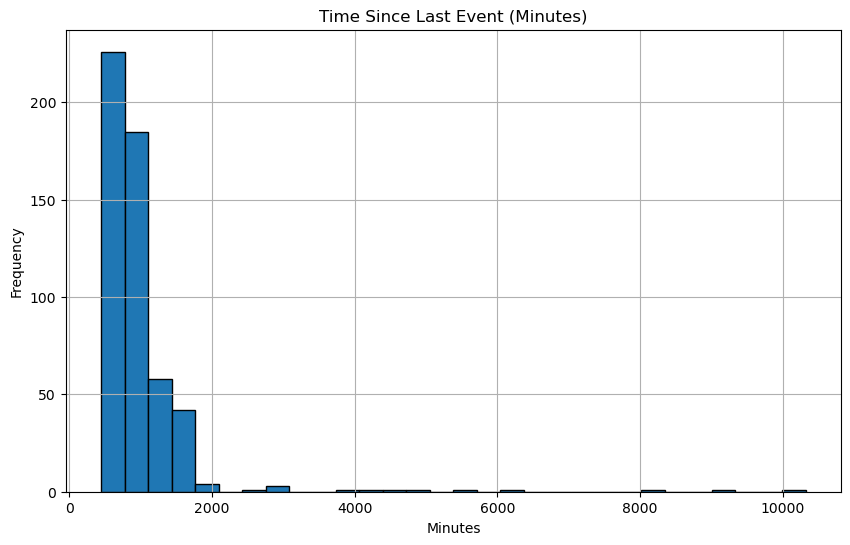

In [41]:
plt.figure(figsize=(10, 6))
plt.hist(df['time_diff_min'][1:], bins=30, edgecolor='black')  # skip first NaN or 0
plt.title("Time Since Last Event (Minutes)")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [56]:
outliers = df[df['time_diff_min'] > 2000]
outliers

,start_time,hour,day_of_week,month,date,time_diff,time_diff_min
281,2010-06-23 23:44:45,23,2,6,2010-06-23,27510.75,6050.00
290,2010-07-01 04:44:45,4,3,7,2010-07-01,30485.00,4455.00
292,2010-07-03 21:14:45,21,5,7,2010-07-03,44180.00,2660.00
316,2010-07-20 02:14:00,2,1,7,2010-07-20,160119.00,2904.25
317,2010-07-23 10:00:30,10,4,7,2010-07-23,247633.75,4786.50
322,2010-07-29 06:39:00,6,3,7,2010-07-29,-67590.75,4019.25
323,2010-08-03 20:49:45,20,1,8,2010-08-03,-119198.50,8050.75
335,2010-08-12 23:34:00,23,3,8,2010-08-12,244184.00,2789.25
336,2010-08-16 21:56:30,21,0,8,2010-08-16,-108457.00,5662.50
338,2010-08-24 09:44:45,9,1,8,2010-08-24,-35825.00,10323.00


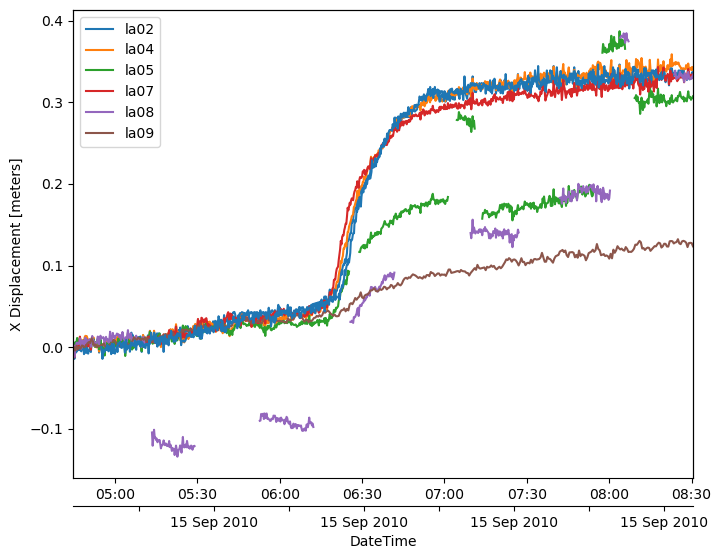

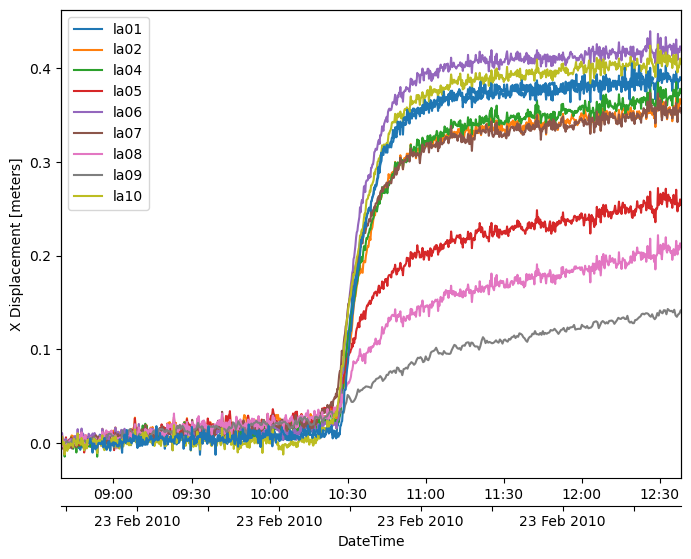

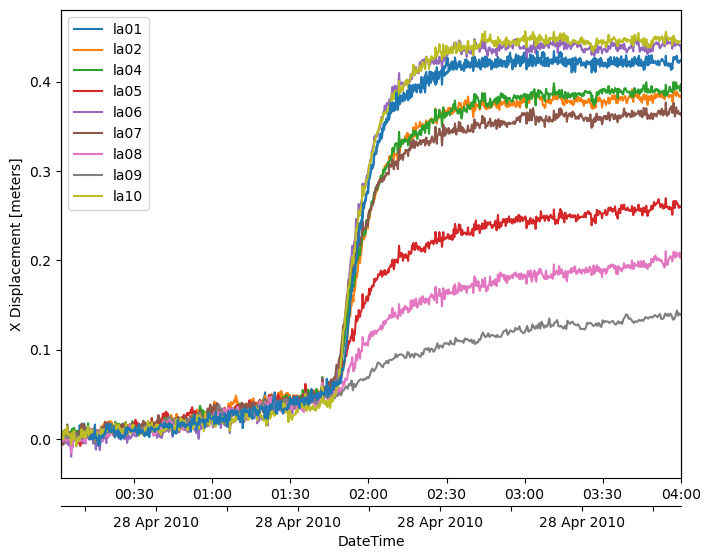

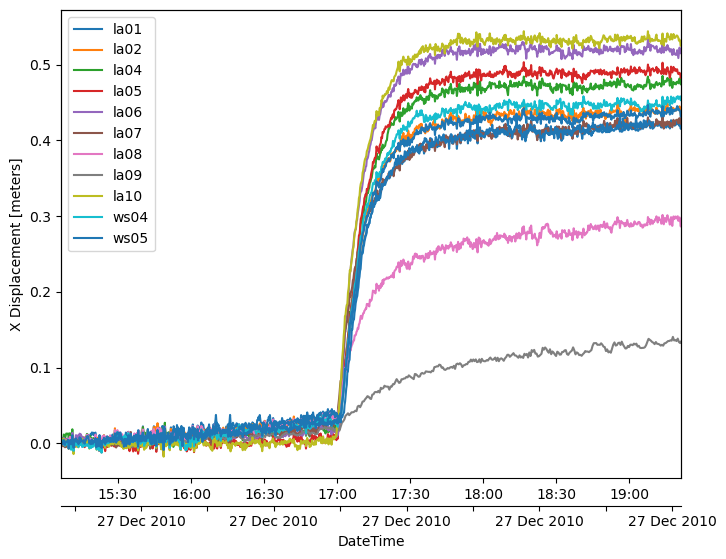

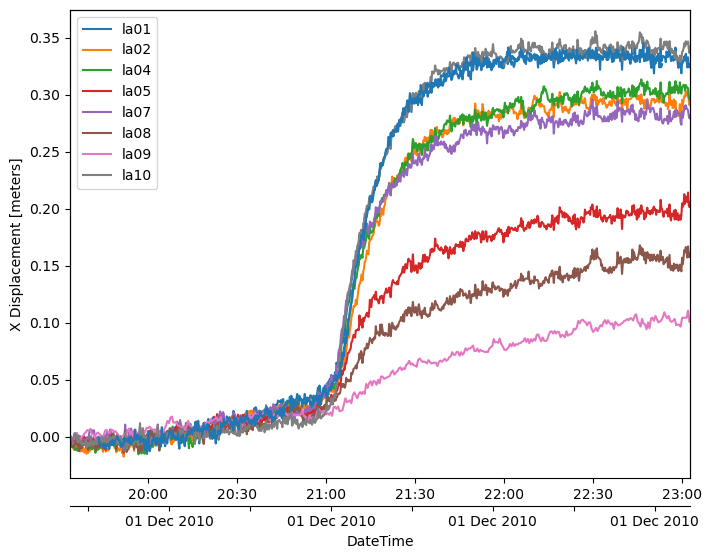

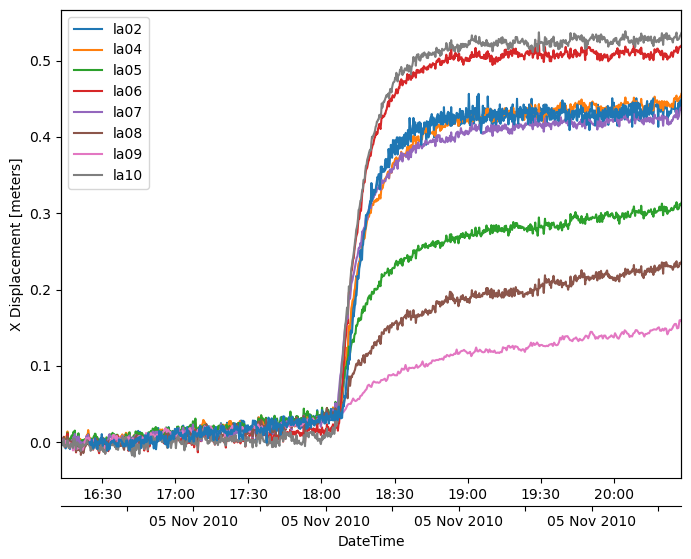

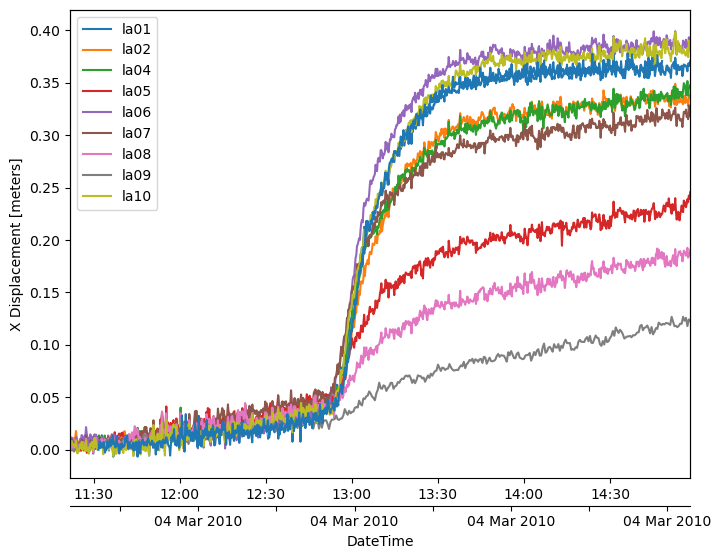

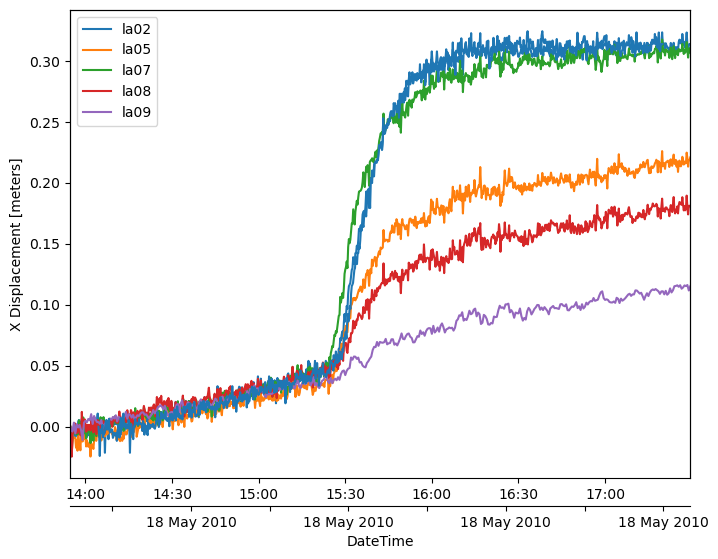

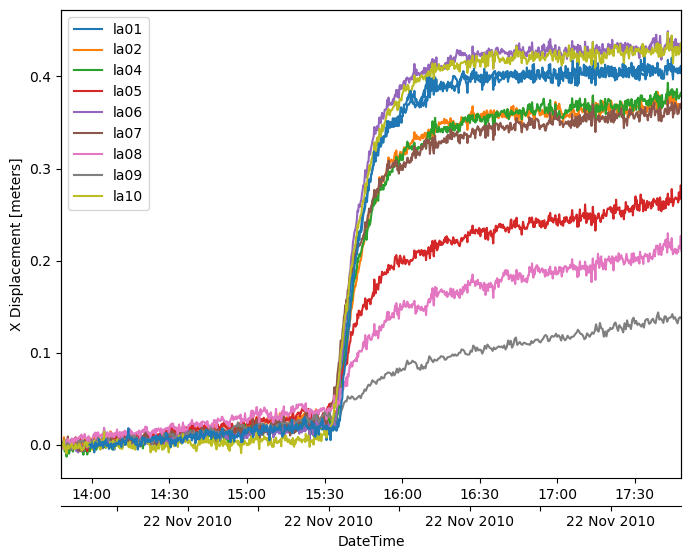

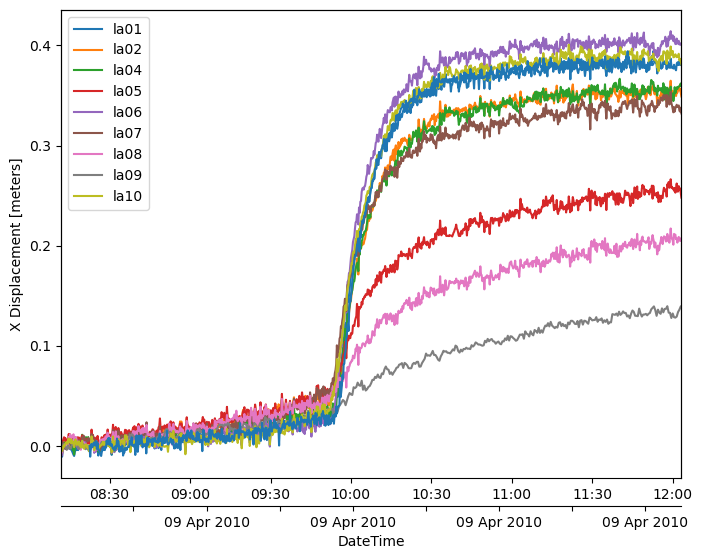

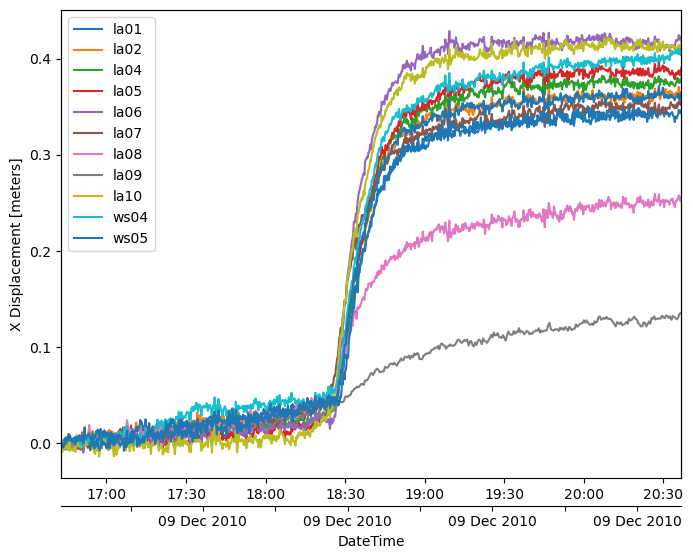

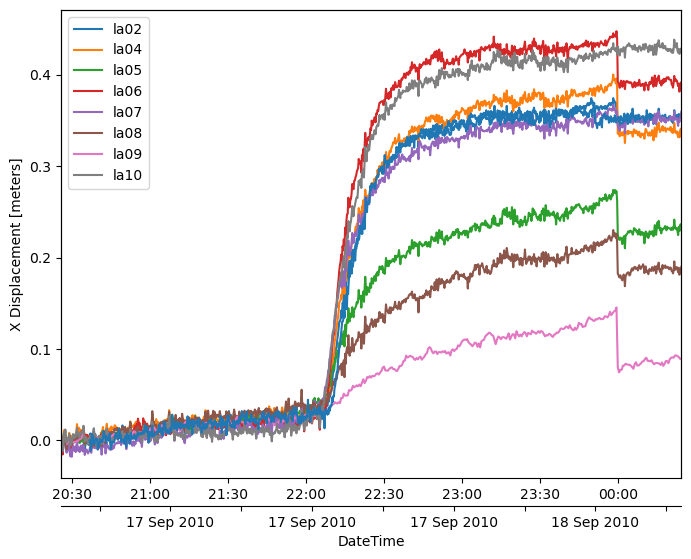

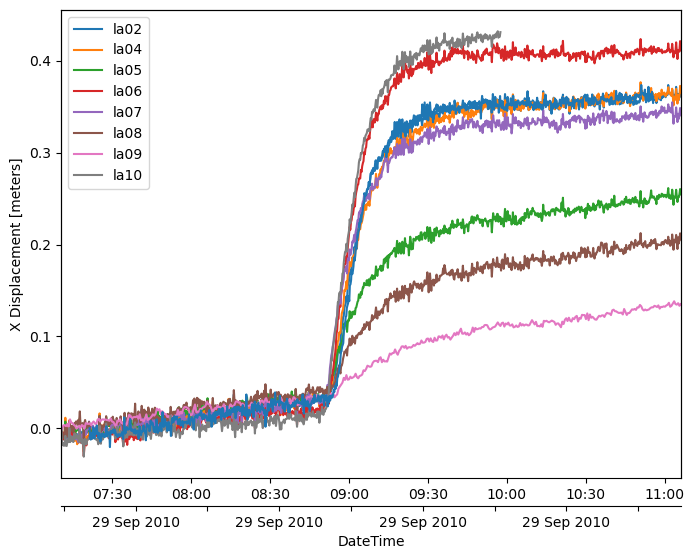

In [62]:
for idx in outliers.index:
    # print(idx)
    plot_event(events_list[idx], var='x')

In [52]:
def plot_event(event: pd.DataFrame, var="x") -> None:
    """
    Plot

    Parameters
    ----------
    event : pd.DataFrame
        Event to plot
    var : str
        Variable to plot.
        Valid options: 'x', 'y', 'z'
    """

    fig, ax1 = plt.subplots(figsize=(8, 6))
    times = pd.to_datetime(event["time"])
    sta_name_len = 4  # Length of station name for title
    plot_cols = [col for col in event if str(col).endswith(var)]

    first = True
    # Loop through stations for plotting
    for plot_col in plot_cols:
        demeaned_to_0 = (event[plot_col] - np.mean(event[plot_col])) - (
            event[plot_col][event.index[0]] - np.mean(event[plot_col])
        )
        if not np.isnan(event[plot_col][event.index[0]]):
            if first:
                ax2_dummy = demeaned_to_0
                first = False
            ax1.plot(times, demeaned_to_0, label=str(plot_col)[:sta_name_len])
    ax1.set_ylabel(f"{var.upper()} Displacement [meters]")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax1.legend()
    ax1.set_xlim(times.iloc[0], times.iloc[-1])

    # Setup dates using second axis
    ax2 = ax1.twiny()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    fig.subplots_adjust(bottom=0.10)
    ax2.set_frame_on(True)
    ax2.patch.set_visible(False)
    ax2.xaxis.set_ticks_position("bottom")
    ax2.xaxis.set_label_position("bottom")
    ax2.spines["bottom"].set_position(("outward", 20))
    ax2.set_xlabel("DateTime")

    # Need to plot something on ax2 to get the correct dates
    ax2.plot(times, ax2_dummy)
    for label in ax2.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)